In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Données
X = np.array([1,2,3,4,5,6,7,8,9,10]).reshape(-1,1)
y = np.array([0,0,0,0,0,1,1,1,1,1])

In [6]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_loss(y_true, y_pred):
    epsilon = 1e-15
    return -np.mean(
        y_true * np.log(y_pred + epsilon) +
        (1 - y_true) * np.log(1 - y_pred + epsilon)
    )

In [7]:
def fit_logistic(X, y, lr=0.1, epochs=1000):

    X_b = np.c_[np.ones((len(X), 1)), X]
    weights = np.zeros(X_b.shape[1])

    for epoch in range(epochs):
        z = np.dot(X_b, weights)
        y_pred = sigmoid(z)

        gradient = np.dot(X_b.T, (y_pred - y)) / len(y)
        weights -= lr * gradient

        if epoch % 200 == 0:
            loss = compute_loss(y, y_pred)
            print(f"Epoch {epoch} | Loss = {loss:.4f}")

    return weights

weights = fit_logistic(X, y)

Epoch 0 | Loss = 0.6931
Epoch 200 | Loss = 0.3080
Epoch 400 | Loss = 0.2268
Epoch 600 | Loss = 0.1888
Epoch 800 | Loss = 0.1661


In [8]:
def predict(X, weights):
    X_b = np.c_[np.ones((len(X), 1)), X]
    proba = sigmoid(np.dot(X_b, weights))
    return (proba >= 0.5).astype(int)

print("3h ->", predict(np.array([[3]]), weights))
print("8h ->", predict(np.array([[8]]), weights))

3h -> [0]
8h -> [1]


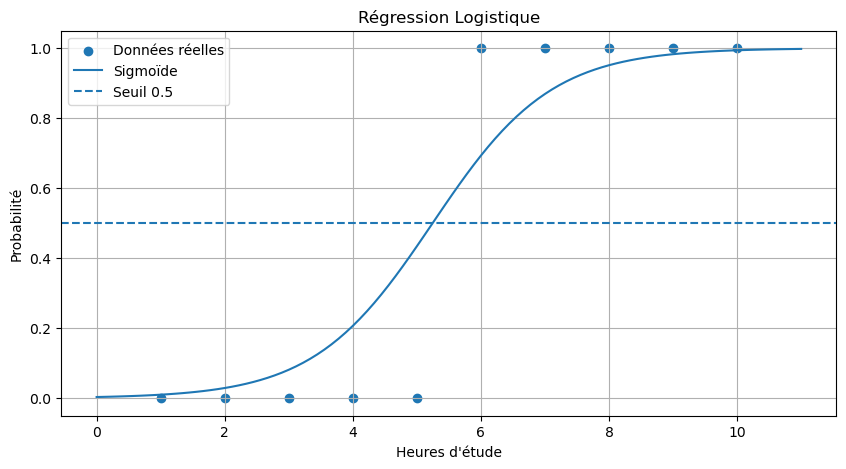

In [9]:
X_test = np.linspace(0, 11, 100).reshape(-1,1)
X_test_b = np.c_[np.ones((100,1)), X_test]
y_prob = sigmoid(np.dot(X_test_b, weights))

plt.figure(figsize=(10,5))
plt.scatter(X, y, label="Données réelles")
plt.plot(X_test, y_prob, label="Sigmoïde")
plt.axhline(y=0.5, linestyle='--', label="Seuil 0.5")

plt.xlabel("Heures d'étude")
plt.ylabel("Probabilité")
plt.title("Régression Logistique")
plt.legend()
plt.grid()
plt.show()

In [10]:
# Régression Logistique From Scratch

Ce notebook implémente une régression logistique avec NumPy pour prédire la réussite (0 ou 1) en fonction des heures d'étude.

SyntaxError: unterminated string literal (detected at line 3) (742021264.py, line 3)